# Assignment 5

Welcome to the assignment for week 5.

## Task 5: Optical Flow

### Task 5.1: Block Matching

* Implement the block matching method as shown in the lecture
* Take two frames from the datasets "lane_detection" or "copter_flight" with variable distances in time (1, 2, x) and compute the vector flow field
* Display a subset of flow vectors on the gray-value version of the first image, by drawing a respective line. adjust the grid density such that not too many vectors overlap (**RESULT**)

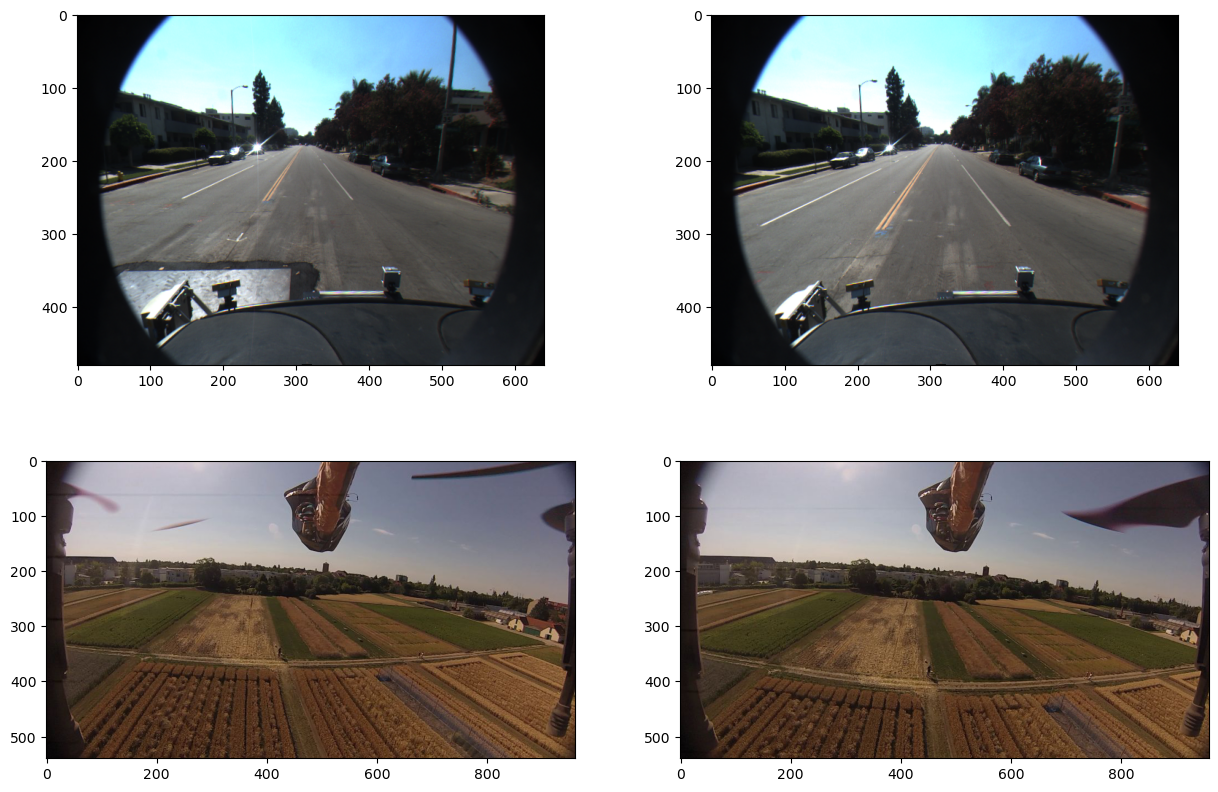

In [1]:
%matplotlib inline 
import matplotlib.pyplot as plt
from skimage import io, data, feature, color, filters
import numpy as np
import matplotlib.patches as patches
import cv2

# Chose other images if you like
lane1 = io.imread('images/lane_detection/f00000.png')
lane2 = io.imread('images/lane_detection/f00001.png')

copter1 = io.imread('images/copter_flight/frame050.jpg')
copter2 = io.imread('images/copter_flight/frame052.jpg')

plt.close()
fig = plt.figure(figsize=(15, 10))
ax11 = plt.subplot(2, 2, 1)
ax12 = plt.subplot(2, 2, 2)
ax21 = plt.subplot(2, 2, 3)
ax22 = plt.subplot(2, 2, 4)

ax11.imshow(lane1)
ax12.imshow(lane2)

ax21.imshow(copter1)
ax22.imshow(copter2)
plt.show()

In [2]:
def blockmatching(image1,image2,grid_dansity):
    image1 = color.rgb2gray(image1)
    image2 = color.rgb2gray(image2)
    window1 = image1[185:210,163:210]
    window2 = image2[185:210,163:210]
    y_block_start, y_block_end = 6, 12
    x_block_start, x_block_end = 17, 40
    block1 = window1[y_block_start:y_block_end, x_block_start:x_block_end]
    h_block, w_block = block1.shape
    y_image, x_image = window2.shape

    flow_vector = []

    for v in range (-y_block_start, y_image - y_block_start,grid_dansity):
        for u in range (-x_block_start, x_image - x_block_start,grid_dansity):
            diff = 0
            y_cand, x_cand = y_block_start + v, x_block_start + u
            if y_cand < 0 or x_cand < 0 or y_cand + h_block > y_image or x_cand + w_block > x_image:
                continue 
            block_cand = window2[y_cand:(y_cand + h_block), x_cand:(x_cand + w_block)]
            for i in range (h_block):
                for j in range (w_block):
                    diff += (block1[i][j] - block_cand[i][j])
            ssd = np.square(diff)
            flow_vector.append((v,u,ssd))
    return flow_vector,window1



35
(2, -9, 0.0005228306419067248)


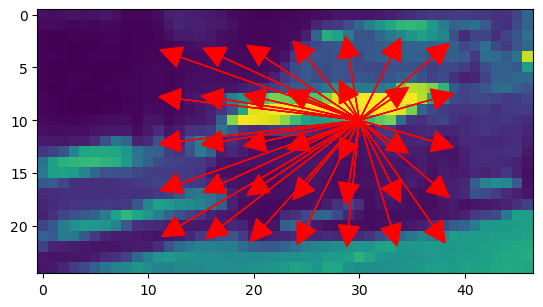

In [3]:
flow_vector,window1 = blockmatching(lane1,lane2,4)
min_flow_vector = min(flow_vector, key=lambda x: x[2])

print(len(flow_vector))
print(min_flow_vector)

plt.close()
plt.imshow(window1)
for (v,u,ssd) in flow_vector:
    plt.arrow(30,10,u,v,color = 'r', head_width = 2, head_length = 2, linewidth = 1)


# plot min arrow on image
# plt.arrow(30,10,min_flow_vector[1],min_flow_vector[0],color = 'r', head_width = 2, head_length = 2, linewidth = 1)
'''
for the origin image 
plt.close()
plt.imshow(lane1)
for (v,u,ssd) in flow_vector:
    plt.arrow(194,185,u,v,color = 'r', head_width = 2, head_length = 2, linewidth = 1)
'''

plt.show()

### Task 5.2: Harris Corner Detection

* Implement the Harris Corner Detector as discussed in the lecture
* Compute and Plot the Harris Corners for the the two images given at the top of this assignment (**RESULT**)

(104, 2)


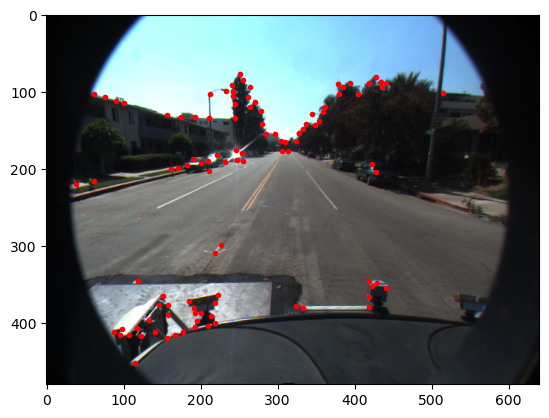

In [32]:


def harris_corner (image):
    image_gray = color.rgb2gray(image)
    Ix, Iy = filters.sobel_h(image_gray), filters.sobel_v(image_gray)
    Ixx = filters.gaussian(np.square(Ix), sigma = 1)
    Iyy = filters.gaussian(np.square(Iy), sigma = 1)
    Iyx = filters.gaussian(Ix * Iy, sigma = 1)

    detA = Ixx*Iyy - np.square(Iyx)
    traceA = Ixx + Iyy
    k = 0.04

    R = detA - k * np.square(traceA)
    threshold = 0.04 * R.max()
    corners = feature.peak_local_max(R, min_distance = 5, threshold_abs = threshold)


    return corners


corners1 = harris_corner(lane1)
print(corners1.shape)
plt.close()
fig, ax = plt.subplots()
ax.imshow(lane1)
ax.plot(corners1[:, 1], corners1[:, 0], 'ro', markersize=3)
plt.show()

(106, 2)


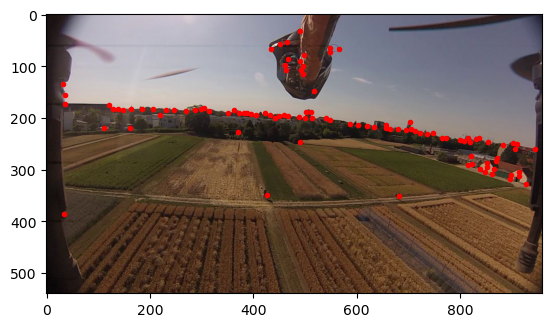

In [33]:
corners2 = harris_corner(copter1)
print(corners2.shape)
plt.close()
fig, ax = plt.subplots()
plt.imshow(copter1)
ax.plot(corners2[:, 1], corners2[:, 0], 'ro', markersize=3)
plt.show()

### Task 5.3: Lucas Kanade

* For the corner images from Task 5.2, track them with Lucas Kanade (feel free to use e.g. the function "calcOpticalFlowPyrLK" in OpenCV)
* Mark the positions of your Harris Corners and draw the flow vectors found by Lucas-Kanade on the gray-value versions of the two images given in the beginning of this assignment (**RESULT**)


In [40]:
def lucas_kanade_optical_flow(image1,image2):
    # Load two consecutive frames
    prev_frame = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    next_frame = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # Step 1: Detect corners in the previous frame
    corners = cv2.goodFeaturesToTrack(prev_frame, maxCorners=100, qualityLevel=0.01, minDistance=10)
    corners = corners.astype(np.float32)



    # Step 2: Calculate Optical Flow
    lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
    next_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_frame, next_frame, corners, None, **lk_params)


    # Filter valid points
    good_prev_pts = corners[status.ravel() == 1]
    good_next_pts = next_pts[status.ravel() == 1]

    # Step 3: Visualize Optical Flow
    # Convert next_frame to color for visualization
    output = cv2.cvtColor(next_frame, cv2.COLOR_GRAY2BGR)
    for i, (prev, next) in enumerate(zip(good_prev_pts, good_next_pts)):
        x1, y1 = prev.ravel()
        x2, y2 = next.ravel()
        cv2.arrowedLine(output, (int(x1), int(y1)), (int(x2), int(y2)), color=(0, 255, 0), thickness=2, tipLength=0.3)

    return output





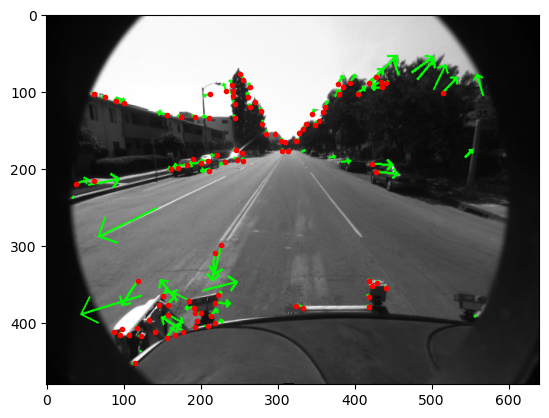

In [41]:
flowVector = lucas_kanade_optical_flow(lane1,lane2)
plt.close()
fig, ax = plt.subplots()
ax.plot(corners1[:, 1], corners1[:, 0], 'ro', markersize=3)
ax.imshow(flowVector)
plt.show()

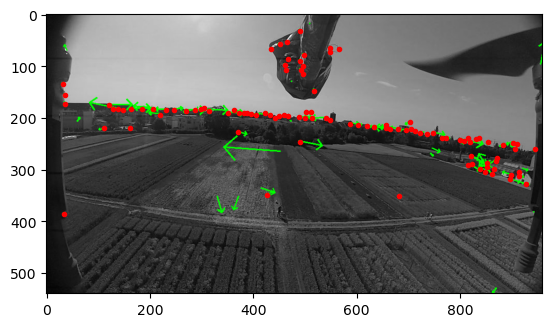

: 

In [ ]:
flowVector = lucas_kanade_optical_flow(copter1,copter2)
plt.close()
fig, ax = plt.subplots()
ax.plot(corners2[:, 1], corners2[:, 0], 'ro', markersize=3)
ax.imshow(flowVector)
plt.show()

## Congratz, you made it! :)